## EBM fit

install https://github.com/kurmukovai/ebm-progression by cloning the repo and `pip install -e .`

In [ ]:
from ebm.probability import log_distributions, fit_distributions, predict_stage
from ebm.mcmc import greedy_ascent, mcmc
from ebm.likelihood import EventProbabilities

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [59]:


X_val = np.load("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/X_val_68biom.npy", allow_pickle = True)
X_train = np.load("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/X_train_68biom.npy", allow_pickle= True)
K = np.load("/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/K_68.npy")

biomarker_names = ['L_bankssts_thickavg', 'L_caudalanteriorcingulate_thickavg', 'L_caudalmiddlefrontal_thickavg', 'L_cuneus_thickavg',
                   'L_entorhinal_thickavg', 'L_fusiform_thickavg', 'L_inferiorparietal_thickavg', 'L_inferiortemporal_thickavg',
                   'L_isthmuscingulate_thickavg', 'L_lateraloccipital_thickavg', 'L_lateralorbitofrontal_thickavg',
                   'L_lingual_thickavg', 'L_medialorbitofrontal_thickavg', 'L_middletemporal_thickavg', 'L_parahippocampal_thickavg',
                   'L_paracentral_thickavg', 'L_parsopercularis_thickavg', 'L_parsorbitalis_thickavg', 'L_parstriangularis_thickavg',
                   'L_pericalcarine_thickavg', 'L_postcentral_thickavg', 'L_posteriorcingulate_thickavg', 'L_precentral_thickavg',
                   'L_precuneus_thickavg', 'L_rostralanteriorcingulate_thickavg', 'L_rostralmiddlefrontal_thickavg', 'L_superiorfrontal_thickavg',
                   'L_superiorparietal_thickavg', 'L_superiortemporal_thickavg', 'L_supramarginal_thickavg', 'L_frontalpole_thickavg',
                   'L_temporalpole_thickavg', 'L_transversetemporal_thickavg', 'L_insula_thickavg', 'R_bankssts_thickavg', 'R_caudalanteriorcingulate_thickavg',
                   'R_caudalmiddlefrontal_thickavg', 'R_cuneus_thickavg', 'R_entorhinal_thickavg', 'R_fusiform_thickavg', 'R_inferiorparietal_thickavg',
                   'R_inferiortemporal_thickavg', 'R_isthmuscingulate_thickavg', 'R_lateraloccipital_thickavg', 'R_lateralorbitofrontal_thickavg',
                   'R_lingual_thickavg', 'R_medialorbitofrontal_thickavg', 'R_middletemporal_thickavg', 'R_parahippocampal_thickavg', 'R_paracentral_thickavg',
                   'R_parsopercularis_thickavg', 'R_parsorbitalis_thickavg', 'R_parstriangularis_thickavg', 'R_pericalcarine_thickavg', 'R_postcentral_thickavg',
                   'R_posteriorcingulate_thickavg', 'R_precentral_thickavg', 'R_precuneus_thickavg', 'R_rostralanteriorcingulate_thickavg',
                   'R_rostralmiddlefrontal_thickavg', 'R_superiorfrontal_thickavg', 'R_superiorparietal_thickavg', 'R_superiortemporal_thickavg',
                   'R_supramarginal_thickavg', 'R_frontalpole_thickavg', 'R_temporalpole_thickavg', 'R_transversetemporal_thickavg', 'R_insula_thickavg']


def unpack_patient_list(patient_list):
    X_obs = []
    dt = []
    ids = []
    cog = []
    nhy = []
    for patient in patient_list:
        n_visits = patient["dt"].shape[0]
        pid = patient["id"]
        X_obs.append(patient["X_obs"])
        dt.append(patient["dt"])
        ids.append(np.full(n_visits, pid))
        cog.append(patient["cog"])
        nhy.append(patient["nhy"])
    return (
        np.vstack(X_obs),
        np.concatenate(dt),
        np.concatenate(ids),
        np.vstack(cog),
        np.concatenate(nhy),
    )

    
X_train_obs, X_train_dt, X_train_ids, X_train_cog, X_train_nhy = unpack_patient_list(X_train)
X_val_obs, X_val_dt, X_val_ids, X_val_cog, X_val_nhy = unpack_patient_list(X_val)

y_val = np.ones(X_val_obs.shape[0])
y_train = np.ones(X_train_obs.shape[0])

df_td = pd.read_csv("/data01/bgutman/MRI_data/PPMI/PPMI_regional_TD.csv")
df_pg = pd.read_csv("/data01/bgutman/MRI_data/PPMI/PPMI_regional_PIGD.csv")

y_td = df_td["Dx"].to_numpy()
y_pg = df_pg["Dx"].to_numpy()

#print(df_td.head(1))

df_td = df_td[biomarker_names].copy()
X_td = df_td[[col for col in df_td.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_td = X_td.to_numpy()
X_td = np.max(X_td, axis=0) - X_td

df_pg = df_pg[biomarker_names].copy()
X_pg = df_pg[[col for col in df_pg.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_pg = X_pg.to_numpy()
X_pg = np.max(X_td, axis=0) - X_pg



# biomarker_names_2 = [col for col in df_td.columns 
#                    if col.startswith(('L_', 'R_')) and 
#                    col.endswith('_thickavg') and 
#                    not col.endswith('_thickavg_resid')]
#print(Xtd.head)

X_val = X_val_obs
y_val = y_val

X_full = np.vstack([X_td, X_pg, X_train_obs])
y_full = np.concatenate([y_td, y_pg, y_train])

log_p_e, log_p_not_e = log_distributions(X=X_full, y=y_full, point_proba=False)

starting_order = np.arange(0,68, dtype=int)
rng = np.random.RandomState(75)
rng.shuffle(starting_order)
print(starting_order)

[31 65 61  2 13 18 11 27 41 29  3 21 49  4 22 44 40  5 53 59 12 58  9 39
 62 60 66 23 33 24 50 15  1 46 57 54 37 56 35 52 14 67 10 28 47 20 16  0
 30 48 36 42 38 45 25 43 51 63 55  7 32 17 34  6 26 64  8 19]


In [60]:
order, loglike, update_iters = greedy_ascent(log_p_e, log_p_not_e, 
                                             n_iter=10_000, order = starting_order,
                                             random_state=2020, prior=K)

100%|██████████| 10000/10000 [00:14<00:00, 672.98it/s]


In [61]:
# almost correct, good job
order

array([46, 67,  8, 12,  4, 33, 50, 47, 55, 39, 11, 42, 45, 41, 43, 40, 44,
       57,  5, 13,  7, 10,  6,  9, 29, 28, 23,  2, 37,  3, 36, 62, 27, 61,
       54, 53, 15, 19, 20, 49, 22, 32, 56, 63, 16, 25, 26, 17, 52, 58, 60,
       59, 64, 51, 21, 30, 18, 24,  1,  0, 34, 31, 65, 38, 48, 14, 66, 35])

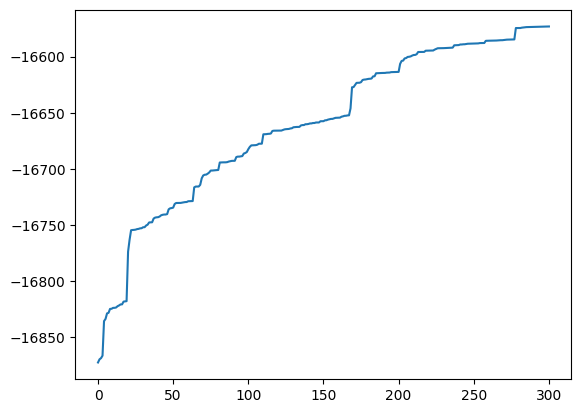

In [62]:
plt.plot(loglike)

In [63]:
orders, loglike, update_iters, probas = mcmc(log_p_e, log_p_not_e,
                                                 order=order, n_iter=500_000,
                                                 random_state=2020)

100%|██████████| 500000/500000 [12:11<00:00, 683.08it/s]


In [64]:
#orders[:10]
print(len(orders))
if orders == []:
    best_order = order
else:
    best_order = orders[np.argmax(loglike)]
    
print(np.array(best_order))

199767
[46 67 43 12  4 33 50 47 55 39 11 42 45 41  8 40 44 57  5 13  7 10  6  9
 29 28 23  2 37  3 36 62 27 61 54 53 15 19 20 49 22 32 56 63 16 25 26 17
 52 58 60 59 64 51 21 30 18 24  1  0 34 31 65 38 48 14 66 35]


In [67]:
#best_order = [41,39,62,32,47,56,34,13,63,2,36,26,7,29,22,60,40,23,57,6,48,61,27,9,5,49,28,15,18,67,20,1,0,66,19,37,25,10,59,64,54,51,44,31,53,45,43,52,11,4,35,38,30,16,8,50,33,58,46,42,14,65,21,55,3,12,24,17]


train_log_p_e, train_log_p_not_e = log_distributions(X=X_train_obs, y=y_train, point_proba=False)
test_log_p_e, test_log_p_not_e = log_distributions(X=X_val_obs, y=y_val, point_proba=False)


from ebm.probability import predict_stage

probas = predict_stage(best_order, train_log_p_e, train_log_p_not_e).T
train_stage = np.argmax(probas, axis=1)

probas = predict_stage(best_order, test_log_p_e, test_log_p_not_e).T
test_stage = np.argmax(probas, axis=1)



/home/dsemchin/Progression_models_simulations/ebm/probability.py:15: RuntimeWarning: Mean of empty slice.
  avg = X[y==0, ...].mean(axis=0)
/home/dsemchin/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/dsemchin/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/dsemchin/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/dsemchin/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [69]:

print(len(test_stage), len(X_val_nhy))

from scipy.stats import spearmanr, kendalltau

print(spearmanr(X_train_nhy, train_stage))


print(train_stage)

print(np.sum(np.isnan(X_val_nhy)))
print(np.sum(np.isnan(test_stage)))

103 103
SignificanceResult(statistic=nan, pvalue=nan)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
0
0


/tmp/ipykernel_10990/907213950.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  print(spearmanr(X_train_nhy, train_stage))
